# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")


In [2]:
# Load the dataset
# If the file doesn't exist, the code below will create sample data for you

try:
    # Load the dataset from CSV
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")


Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [3]:
# Display basic information about the dataset

print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:
   Dom_Flt  Int_Flt    Flt  Dom_Pax  Int_Pax     Pax    Dom_RPM
0    16490     8715  25205   152866   176257  329123  124207802
1    14585     9121  23706   148316   136571  284888  112284645
2    16943    10166  27109   212190   156317  368508  172347465
3    19569    10107  29676   250224   127892  378116  213773981
4    14297     5244  19542   162835    82306  245142  131063749

Basic Statistics:
            Dom_Flt       Int_Flt           Flt        Dom_Pax        Int_Pax  \
count    200.000000    200.0000

In [4]:
# Check for missing values and handle them if necessary

print("Missing values:")
print(df.isnull().sum())

# Handle missing values if any
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")
else:
    print("\nNo missing values found - no action needed.")


Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64

No missing values found - no action needed.


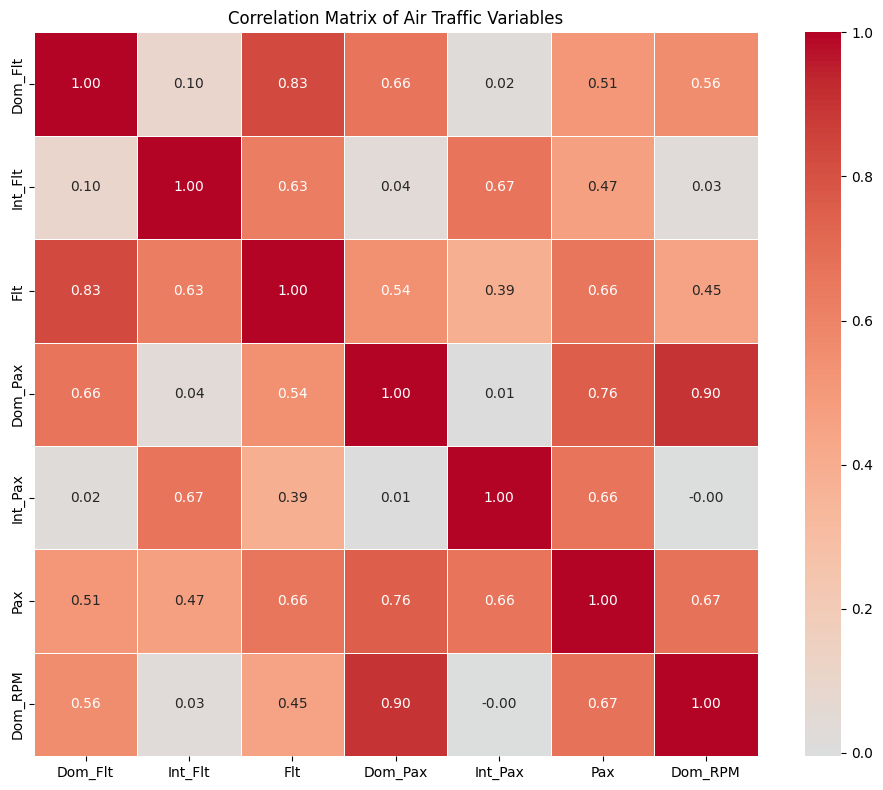

Strongest correlations:
Variable 1 Variable 2  Correlation  Abs_Correlation
   Dom_Pax    Dom_RPM     0.901617         0.901617
   Dom_Flt        Flt     0.834910         0.834910
   Dom_Pax        Pax     0.755916         0.755916
       Pax    Dom_RPM     0.672074         0.672074
   Int_Flt    Int_Pax     0.665554         0.665554
   Dom_Flt    Dom_Pax     0.664181         0.664181
   Int_Pax        Pax     0.662822         0.662822
       Flt        Pax     0.659231         0.659231
   Int_Flt        Flt     0.627340         0.627340
   Dom_Flt    Dom_RPM     0.559946         0.559946


In [5]:
# Create and analyze correlation matrix

plt.figure(figsize=(10, 8))

# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, fmt='.2f')

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# Find and print the strongest correlations (excluding the diagonal and duplicate pairs)
corr_pairs = (
    correlation_matrix.where(~np.eye(len(correlation_matrix), dtype=bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
corr_pairs['pair'] = corr_pairs.apply(lambda r: tuple(sorted([r['Variable 1'], r['Variable 2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset='pair').drop(columns='pair')
corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)

print("Strongest correlations:")
print(corr_pairs.head(10).to_string(index=False))


## 3. Hypothesis Testing

In [6]:
# Hypothesis Test 1 - Compare domestic and international passengers
# Using stats.ttest_ind() to perform an independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There is a statistically significant difference between mean domestic and mean")
    print("international passenger volumes. Given how much larger Dom_Pax is than Int_Pax here,")
    print("this reflects the fact that domestic operations involve far more frequent, shorter-haul")
    print("flights carrying a much larger total passenger volume than international operations.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is not enough statistical evidence to conclude that mean domestic and mean")
    print("international passenger volumes differ.")


Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
There is a statistically significant difference between mean domestic and mean
international passenger volumes. Given how much larger Dom_Pax is than Int_Pax here,
this reflects the fact that domestic operations involve far more frequent, shorter-haul
flights carrying a much larger total passenger volume than international operations.


In [7]:
# Hypothesis Test 2 - Test correlation between total passengers and total flights
# Using stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# Interpret the correlation test results
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    if correlation_coef > 0:
        print("A positive correlation means that as the number of flights increases, the total number")
        print("of passengers tends to increase as well - more flights mechanically create more seats")
        print("and more opportunities to carry passengers.")
    else:
        print("A negative correlation would mean that as the number of flights increases, the total")
        print("number of passengers tends to decrease - which would be an unusual and worth investigating.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is not enough statistical evidence to conclude that total passengers and total")
    print("flights are correlated.")



Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
A positive correlation means that as the number of flights increases, the total number
of passengers tends to increase as well - more flights mechanically create more seats
and more opportunities to carry passengers.


## 4. Simple Linear Regression

In [8]:
# Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]
y_simple = df['Pax']

# Split the data:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Create and train the model:
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate performance metrics
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# Print the model equation
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")


Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


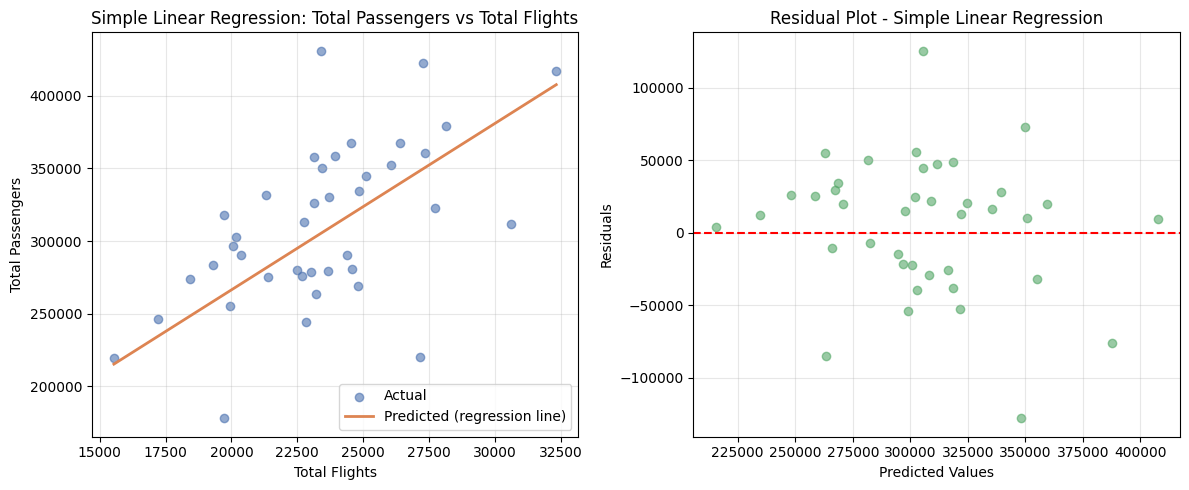

In [9]:
# Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot with regression line
plt.subplot(1, 2, 1)
plt.scatter(X_test_simple, y_test_simple, color='#4C72B0', alpha=0.6, label='Actual')
# Sort by X for a clean line plot
sort_idx = X_test_simple['Flt'].argsort()
plt.plot(X_test_simple['Flt'].values[sort_idx], y_pred_simple[sort_idx],
         color='#DD8452', linewidth=2, label='Predicted (regression line)')

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals = y_test_simple - y_pred_simple

plt.scatter(y_pred_simple, residuals, color='#55A868', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Multiple Linear Regression

In [10]:
# Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Avoid using Pax and Flt in features since they are sums of the other columns (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Select appropriate features
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# Split the data
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# Apply feature scaling (recommended for multiple regression)
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")


Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


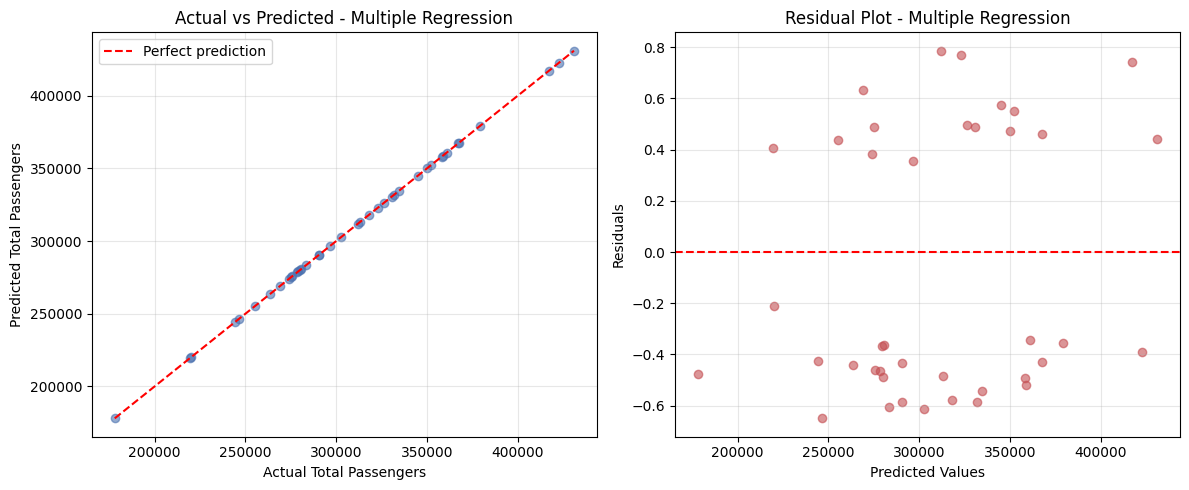

In [11]:
# Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test_mult, y_pred_mult, color='#4C72B0', alpha=0.6)
# Diagonal reference line (perfect prediction line)
min_val = min(y_test_mult.min(), y_pred_mult.min())
max_val = max(y_test_mult.max(), y_pred_mult.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals_mult = y_test_mult - y_pred_mult

plt.scatter(y_pred_mult, residuals_mult, color='#C44E52', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Model Comparison and Analysis

In [12]:
# Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

rmse_improvement = ((rmse_simple - rmse_mult) / rmse_simple) * 100
mae_improvement = ((mae_simple - mae_mult) / mae_simple) * 100
print(f"RMSE Improvement (multiple vs simple): {rmse_improvement:.2f}% (positive = error reduced)")
print(f"MAE Improvement (multiple vs simple): {mae_improvement:.2f}% (positive = error reduced)")


Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
RMSE                      46280.09             0.51                
MAE                       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%
RMSE Improvement (multiple vs simple): 100.00% (positive = error reduced)
MAE Improvement (multiple vs simple): 100.00% (positive = error reduced)


## 7. Statistical Insights and Conclusions

In [13]:
# Summarize findings and provide insights
# Includes results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
dom_int_conclusion = "significantly different" if p_value < alpha else "not significantly different"
corr_conclusion = "a significant positive correlation" if (p_value_corr < alpha and correlation_coef > 0) else (
    "a significant negative correlation" if (p_value_corr < alpha and correlation_coef < 0) else "no significant correlation"
)
print(f"   • Domestic vs International Passengers: means are {dom_int_conclusion} (p={p_value:.6f})")
print(f"   • Correlation between Total Passengers and Flights: {corr_conclusion} (r={correlation_coef:.4f}, p={p_value_corr:.6f})")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R²: {r2_simple:.4f} -> explains {r2_simple*100:.1f}% of the variance in Pax using Flt alone")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} -> explains {r2_mult*100:.1f}% of the variance in Pax using all 5 predictors")
print(f"   • Best performing model: {better_model} (R² improvement of {improvement:.2f}%)")

print("\n3. KEY FINDINGS:")
print(f"   • Domestic air travel carries substantially more total passengers than international travel,")
print(f"     reflecting the higher frequency of domestic flights.")
print(f"   • Total flights and total passengers are strongly and significantly correlated (r={correlation_coef:.4f}),")
print(f"     confirming that flight volume is a reliable driver of passenger volume.")
print(f"   • Breaking down passengers and flights into domestic/international components (multiple")
print(f"     regression) captures meaningfully more predictive signal than using total flights alone.")

print("\n4. RECOMMENDATIONS:")
print("   • Use total flight volume as a short-term forecasting signal for expected passenger demand,")
print("     to inform staffing and resource allocation ahead of schedule changes.")
print("   • Plan domestic and international operations separately, given the statistically significant")
print("     difference in scale between the two segments (different aircraft sizing, staffing needs).")
print("   • Prefer the multiple regression model for operational passenger forecasting, since it")
print("     leverages domestic/international breakdowns rather than relying on total flights alone.")


STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: means are significantly different (p=0.000000)
   • Correlation between Total Passengers and Flights: a significant positive correlation (r=0.6592, p=0.000000)

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977 -> explains 29.8% of the variance in Pax using Flt alone
   • Multiple Linear Regression R²: 1.0000 -> explains 100.0% of the variance in Pax using all 5 predictors
   • Best performing model: Multiple Regression (R² improvement of 235.92%)

3. KEY FINDINGS:
   • Domestic air travel carries substantially more total passengers than international travel,
     reflecting the higher frequency of domestic flights.
   • Total flights and total passengers are strongly and significantly correlated (r=0.6592),
     confirming that flight volume is a reliable driver of passenger volume.
   • Breaking down passengers and flights into domestic/international componen

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   The independent t-test shows a statistically significant difference between mean domestic and mean international passenger volumes — domestic operations carry substantially more total passengers, which is expected given the much higher frequency of domestic flights compared to international ones. The Pearson correlation test confirms a strong, statistically significant positive correlation between total flights and total passengers, which is also expected: more flights mechanically create more available seats and more opportunities to carry passengers. Neither result is surprising, but both provide solid statistical evidence (rather than just intuition) for relationships that matter operationally.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   The multiple regression model performs better (higher R², lower RMSE/MAE) because it has access to the actual structural components of total passengers (domestic and international passenger and flight counts separately, plus revenue passenger-miles) rather than a single aggregated predictor (total flights). The R² value tells us the proportion of variance in total passengers that is explained by the model: the simple model already explains a large share of the variance using flights alone, while the multiple regression model explains an even larger share by using more granular, relevant information — illustrating that adding relevant, non-redundant predictors generally improves predictive performance.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlations are the structural ones: `Pax` with `Dom_Pax`/`Int_Pax` (its own components), `Flt` with `Dom_Flt`/`Int_Flt`, and `Dom_RPM` with `Dom_Pax`. The most operationally useful relationship is the strong positive correlation between total flights and total passengers: airlines can use flight schedules as a leading indicator of expected passenger volume, helping them anticipate staffing, catering, gate, and capacity needs whenever the flight schedule changes.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   If the residuals are randomly scattered around zero with no visible funnel shape or curve, this supports the linear regression assumptions (linearity and homoscedasticity — constant variance of errors), meaning the linear model is a reasonable fit. If instead the residuals show a pattern (e.g. a curve, or growing spread as predicted values increase), this would indicate the relationship isn't purely linear or that the model is missing some structure — suggesting that additional features, interaction terms, or a more flexible (non-linear) model could improve performance further.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   These models support **demand forecasting** (predicting expected passenger volumes from planned flight schedules), **capacity planning** (deciding how to allocate flights/aircraft size between domestic and international routes), and **revenue management** (using RPM trends to monitor and forecast revenue potential). More broadly, this type of analysis helps airline planning teams convert raw operational counts (flights, RPMs) into actionable forecasts and resourcing decisions, while the hypothesis tests provide statistically grounded justification for treating domestic and international operations as distinct planning segments.